# Notebook 1 — Exploration, nettoyage et stockage de la banque GPX

## Contexte du projet

Construire un planificateur d'itinéraires vélo pour l'Île-de-France, **public
et gratuit**, qui maximise le plaisir du trajet plutôt que la distance. La
motivation : Google Maps, Komoot et Strava Routes optimisent tous un coût
distance/temps avec des profils vélo médiocres pour du vélo de route. Résultat :
on finit sur des départementales avec des camions.

On s'appuie sur :
1. Une **banque club** d'environ 100 traces GPX de boucles validées (= roulées
   et jugées bonnes par des membres)
2. Les **tags OSM** (voies cyclables, hiérarchie routière, vitesse limite…)
3. Les **données ouvertes IdF Mobilités** (pistes cyclables officielles)
4. L'**API Strava Segments** en OAuth officiel (popularité mesurée)
5. Le **feedback utilisateur** post-trajet (notation + reports de danger)
6. Un **modèle ML (PU learning)** qui généralise la notion de "route club-worthy"
   des 100 traces vers les ~500k arêtes d'IdF

## Cadre théorique : Arc Orienteering Problem (AOP)

Le problème formalisé : sur un graphe $G = (V, A)$ avec source $s$, destination
$d$, coût $c(a)$ et score $s(a)$ par arc, et budget $B$, trouver un chemin $P$
qui résout :

$$\max_P \sum_{a \in P} s(a) \quad \text{s.c.} \quad \sum_{a \in P} c(a) \leq B$$

NP-difficile (réduction depuis le sac à dos). En pratique on utilise soit du
Dijkstra pondéré, soit l'approche Lu & Shahabi (plus court chemin + détours
ciblés), soit une métaheuristique GRASP.

**Dans notre cas**, on aura plusieurs budgets simultanés :
- $B_{\text{dist}}$ : budget distance
- $B_{\text{D+}}$ : budget dénivelé (mode grimpeur : on autorise des détours
  qui ajoutent du D+)
- Score $s(a)$ composite fusionnant plusieurs sources

## Papiers fondamentaux

**AOP et cycle planning**
- Verbeeck, Vansteenwegen, Aghezzaf (2014). *An extension of the arc
  orienteering problem and its application to cycle trip planning*.
  Transportation Research Part E, 68:64–78. **Le papier le plus proche.**
- Lu, Shahabi (2015). *An arc orienteering algorithm to find the most scenic
  path on a large-scale road network*. SIGSPATIAL.
- Jossé et al. (2016). *Scenic Routes Now: Efficiently Solving the
  Time-Dependent Arc Orienteering Problem*. arxiv:1609.08484.
- Vansteenwegen, Souffriau, Van Oudheusden (2011). *The orienteering problem:
  a survey*. EJOR 209:1–10.
- Gunawan, Lau, Vansteenwegen (2016). *Orienteering problem: A survey*.
  EJOR 255:315–332.

**Map-matching (Notebook 2)**
- Newson, Krumm (2009). *Hidden Markov map matching through noise and
  sparseness*. ACM SIGSPATIAL.

**PU learning (Notebook 5 — apprendre le score depuis tes 100 traces)**
- Bekker, Davis (2020). *Learning from positive and unlabeled data: a survey*.
  Machine Learning, 109:719–760.
- Elkan, Noto (2008). *Learning classifiers from only positive and unlabeled
  data*. KDD.

**Inverse Reinforcement Learning (pour modéliser les préférences depuis
les choix de route du club)**
- Ziebart et al. (2008). *Navigate like a cabbie: Probabilistic reasoning
  from observed context-aware behavior*. UbiComp. Application directe à la
  modélisation de préférences de déplacement.

**Bandit combinatoire (pour le feedback utilisateur online, mise à jour
continue du score)**
- Kveton et al. (2015). *Tight regret bounds for stochastic combinatorial
  semi-bandits*. AISTATS.

## Plan global du projet

| # | Notebook | Sortie |
|---|----------|--------|
| 0 | Setup DB : install PostgreSQL + PostGIS, création schéma | DB `velo_club` |
| **1 (celui-ci)** | Chargement, validation, visualisation des 100 boucles club, stockage | Traces en DB |
| 2 | Map-matching Valhalla/Meili, découpage en sous-tronçons | `trace_edges` |
| 3 | Graphe OSM enrichi + intégration Strava Segments (OAuth) + data.gouv pistes cyclables | Graphe sérialisé |
| 4 | Baseline Dijkstra pondéré multi-budget (distance + D+) | Premier routing fonctionnel |
| 5 | PU learning : apprentissage d'un score "club-worthy" par arête → généralisation à tout l'IdF | Modèle ML |
| 6 | Algorithme Lu & Shahabi 2015 : plus court chemin + insertion de détours ciblés | Routing de qualité |
| 7 | GRASP complet (Verbeeck 2014) | Routing niveau publication |
| App | Streamlit/FastAPI : UI publique + feedback utilisateur + mode grimpeur | Site online |

## Ce notebook (1) en détail

1. Setup et imports
2. Connexion à PostgreSQL + création du schéma complet
3. Découverte des fichiers GPX
4. Parsing défensif (try/except systématique)
5. Extraction de features numériques (longueur, D+, tortuosité, bbox, …)
6. **Validation que les traces sont bien des boucles** (distance début↔fin)
7. Extraction d'info depuis les noms de fichiers (regex : zone, distance, etc.)
8. **Filtrage géographique IdF** élargi
9. Visualisation sur carte (superposition + inspection individuelle)
10. **Stockage PostGIS** avec géométries `LINESTRING` indexées spatialement
11. Rapport final

## Prérequis

- PostgreSQL 16 + PostGIS installés (Notebook 0)
- Base `velo_club` créée avec `CREATE EXTENSION postgis`
- Env Python avec les packages suivants :

```bash
pip install gpxpy pandas numpy folium matplotlib shapely tqdm scipy \
            psycopg2-binary sqlalchemy geoalchemy2
```


## 1. Imports

Un bloc d'imports unifié. Chaque ligne est commentée pour que tu puisses
retrouver quel package sert à quoi. Tu peux copier-coller tel quel.

In [52]:
# --- Standard library ---
from pathlib import Path                # manipulation de chemins
from datetime import datetime
import re                               # parsing des noms de fichiers
import os
import warnings
warnings.filterwarnings("ignore")

# --- Calcul et data ---
import numpy as np
import pandas as pd
from tqdm.auto import tqdm              # barres de progression dans notebook

# --- Parsing GPX ---
import gpxpy
import gpxpy.gpx

# --- Géométrie ---
from shapely.geometry import LineString, Point
from shapely import wkt                 # lecture/écriture Well-Known Text

# --- Distances géodésiques ---
from math import radians, sin, cos, atan2, sqrt

# --- PostgreSQL / PostGIS ---
from sqlalchemy import create_engine, text
from sqlalchemy.engine import Engine

# --- Visualisation ---
import folium
import matplotlib.pyplot as plt

# --- Options affichage ---
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 220)

print("Imports OK")

Imports OK


## 2. Connexion PostgreSQL et création du schéma complet

### Pourquoi on pose tout le schéma dès maintenant

Le site sera public, avec feedback utilisateur, apprentissage continu,
plusieurs sources de données externes. Il faut penser l'archi une bonne
fois pour toutes maintenant, quitte à créer des tables vides qu'on remplira
aux notebooks suivants.

### Philosophie du schéma

On sépare nettement :
- **Données brutes** : fichiers GPX, points, métadonnées (notebook 1)
- **Données dérivées** : arêtes OSM, heatmap club, segments Strava (notebooks 2-3)
- **Modèle appris** : scores prédits par arête, features (notebook 5)
- **Feedback utilisateur** : notations globales + reports ponctuels
- **Logs d'usage** : trajets demandés par les utilisateurs (pour analytics)

### Tables

| Table | Contenu | Rempli au notebook |
|-------|---------|-------------------|
| `traces` | 1 ligne par boucle GPX, métadonnées + géométrie | 1 |
| `trace_points` | Points GPS bruts de chaque trace | 1 |
| `osm_edges` | Arêtes OSM d'IdF avec tags (highway, surface, cycleway, …) | 3 |
| `trace_edges` | Jointure N-N : trace × arête OSM empruntée | 2 |
| `strava_segments` | Segments Strava importés via OAuth | 3 |
| `edge_scores` | Score final composite par arête (club + OSM + Strava + ML) | 5 |
| `edge_features` | Features ML par arête (pour PU learning) | 5 |
| `user_ratings` | Notation globale d'un trajet par utilisateur | App |
| `user_reports` | Report ponctuel (point + catégorie : danger / top / coup de coeur) | App |
| `route_requests` | Log des trajets demandés par utilisateurs (analytics) | App |


In [53]:
# --- Paramètres de connexion : À REMPLIR AVEC TES INFOS ---
# Recommandation : mets-les dans un fichier .env et charge avec python-dotenv
# Pour le notebook exploratoire on les met en dur, mais jamais en prod publique

DB_CONFIG = {
    "user":     "postgres",
    "password": "4421",          # ← À REMPLACER par ton mot de passe
    "host":     "localhost",
    "port":     5432,
    "database": "velo_club",
}

def get_engine(cfg: dict) -> Engine:
    """
    Retourne un engine SQLAlchemy connecté à la base.
    pool_pre_ping=True : vérifie la connexion avant chaque requête
    (évite les erreurs si la connexion est restée ouverte longtemps).
    """
    url = (
        f"postgresql+psycopg2://{cfg['user']}:{cfg['password']}"
        f"@{cfg['host']}:{cfg['port']}/{cfg['database']}"
    )
    return create_engine(url, pool_pre_ping=True)

engine = get_engine(DB_CONFIG)

# Vérification de la connexion et de PostGIS
with engine.connect() as conn:
    pg_version = conn.execute(text("SELECT version();")).scalar()
    postgis_version = conn.execute(text("SELECT PostGIS_Version();")).scalar()

print("PostgreSQL :", pg_version.split(",")[0])
print("PostGIS    :", postgis_version)

PostgreSQL : PostgreSQL 18.3 on x86_64-windows
PostGIS    : 3.6 USE_GEOS=1 USE_PROJ=1 USE_STATS=1


### Création du schéma complet

On utilise `CREATE TABLE IF NOT EXISTS` pour être idempotent : relancer ce
notebook ne casse rien.

Pour les géométries on utilise le SRID **4326** (WGS84 = lat/lon standard
GPS). Pour les calculs de distance précise, PostGIS permet de passer en
géométrie projetée (ex. Lambert 93 pour la France, SRID 2154) à la volée.

In [54]:
SCHEMA_SQL = """
-- Extension PostGIS (idempotent)
CREATE EXTENSION IF NOT EXISTS postgis;

-- =========================================================================
-- TABLES DE DONNÉES BRUTES (notebook 1)
-- =========================================================================

CREATE TABLE IF NOT EXISTS traces (
    trace_id            SERIAL PRIMARY KEY,
    filename            TEXT NOT NULL,
    path                TEXT NOT NULL UNIQUE,
    name                TEXT,                   -- nom interne GPX
    source_type         TEXT,                   -- 'track' ou 'route'

    -- Features numériques
    n_points            INTEGER,
    length_m            DOUBLE PRECISION,
    duration_s          DOUBLE PRECISION,       -- NULL si pas de timestamps
    speed_kmh_mean      DOUBLE PRECISION,
    elevation_gain_m    DOUBLE PRECISION,       -- D+ total
    elevation_loss_m    DOUBLE PRECISION,       -- D-
    max_elevation_m     DOUBLE PRECISION,
    min_elevation_m     DOUBLE PRECISION,

    -- Validation boucle
    start_end_crow_m    DOUBLE PRECISION,
    is_loop             BOOLEAN,                -- TRUE si start_end_crow_m < 500 m
    tortuosity          DOUBLE PRECISION,       -- length / start_end_crow_m

    -- Infos parsées depuis le nom de fichier
    parsed_zone         TEXT,                   -- "chevreuse", "fontainebleau", …
    parsed_distance_km  DOUBLE PRECISION,       -- si présent dans le nom
    parsed_difficulty   TEXT,                   -- "facile", "difficile", …

    -- Bounding box (pour filtrage spatial rapide sans index géo)
    bbox_lon_min        DOUBLE PRECISION,
    bbox_lat_min        DOUBLE PRECISION,
    bbox_lon_max        DOUBLE PRECISION,
    bbox_lat_max        DOUBLE PRECISION,

    -- Flags
    is_idf              BOOLEAN DEFAULT TRUE,   -- trace en Île-de-France

    -- Géométrie complète de la trace
    geom                GEOMETRY(LineString, 4326),

    created_at          TIMESTAMP DEFAULT NOW()
);

CREATE INDEX IF NOT EXISTS idx_traces_geom
    ON traces USING GIST (geom);
CREATE INDEX IF NOT EXISTS idx_traces_is_loop
    ON traces (is_loop, is_idf);

CREATE TABLE IF NOT EXISTS trace_points (
    trace_id    INTEGER NOT NULL,
    seq         INTEGER NOT NULL,
    lat         DOUBLE PRECISION NOT NULL,
    lon         DOUBLE PRECISION NOT NULL,
    ele         DOUBLE PRECISION,
    time        TIMESTAMP,
    PRIMARY KEY (trace_id, seq),
    FOREIGN KEY (trace_id) REFERENCES traces (trace_id) ON DELETE CASCADE
);

CREATE INDEX IF NOT EXISTS idx_points_trace
    ON trace_points (trace_id);

-- =========================================================================
-- TABLES POUR LES NOTEBOOKS 2-3 (arêtes OSM + jointures)
-- On crée les tables vides maintenant pour fixer le schéma
-- =========================================================================

CREATE TABLE IF NOT EXISTS osm_edges (
    edge_id         BIGSERIAL PRIMARY KEY,
    osm_way_id      BIGINT,                 -- ID de la way OSM source
    u               BIGINT,                 -- node source
    v               BIGINT,                 -- node destination
    length_m        DOUBLE PRECISION,
    highway         TEXT,                   -- 'primary', 'secondary', …
    cycleway        TEXT,
    surface         TEXT,
    maxspeed        INTEGER,
    bicycle         TEXT,                   -- 'yes' / 'no' / 'designated'
    oneway          BOOLEAN,
    lcn             BOOLEAN DEFAULT FALSE,  -- local cycle network
    rcn             BOOLEAN DEFAULT FALSE,  -- regional cycle network
    is_contraflow   BOOLEAN DEFAULT FALSE,  -- contre-sens cyclable
    ele_start_m     DOUBLE PRECISION,
    ele_end_m       DOUBLE PRECISION,
    gradient        DOUBLE PRECISION,
    geom            GEOMETRY(LineString, 4326)
);

CREATE INDEX IF NOT EXISTS idx_osm_edges_geom
    ON osm_edges USING GIST (geom);
CREATE INDEX IF NOT EXISTS idx_osm_edges_uv
    ON osm_edges (u, v);

CREATE TABLE IF NOT EXISTS trace_edges (
    trace_id    INTEGER NOT NULL,
    edge_id     BIGINT NOT NULL,
    seq         INTEGER,
    PRIMARY KEY (trace_id, edge_id, seq),
    FOREIGN KEY (trace_id) REFERENCES traces (trace_id) ON DELETE CASCADE,
    FOREIGN KEY (edge_id)  REFERENCES osm_edges (edge_id) ON DELETE CASCADE
);

-- =========================================================================
-- SOURCES EXTERNES (notebook 3)
-- =========================================================================

CREATE TABLE IF NOT EXISTS strava_segments (
    segment_id      BIGINT PRIMARY KEY,     -- ID Strava natif
    name            TEXT,
    activity_type   TEXT,                   -- 'Ride', …
    distance_m      DOUBLE PRECISION,
    average_grade   DOUBLE PRECISION,
    effort_count    INTEGER,                -- popularité
    star_count      INTEGER,
    geom            GEOMETRY(LineString, 4326),
    fetched_at      TIMESTAMP DEFAULT NOW()
);

CREATE INDEX IF NOT EXISTS idx_strava_geom
    ON strava_segments USING GIST (geom);

-- =========================================================================
-- MODÈLE APPRIS (notebook 5)
-- =========================================================================

CREATE TABLE IF NOT EXISTS edge_scores (
    edge_id         BIGINT PRIMARY KEY,
    score_club      DOUBLE PRECISION DEFAULT 0,   -- issu de trace_edges
    score_osm       DOUBLE PRECISION DEFAULT 0,   -- issu de tags OSM
    score_strava    DOUBLE PRECISION DEFAULT 0,   -- issu popularité Strava
    score_ml        DOUBLE PRECISION DEFAULT 0,   -- prédit par PU learning
    score_final     DOUBLE PRECISION DEFAULT 0,   -- combinaison pondérée
    updated_at      TIMESTAMP DEFAULT NOW(),
    FOREIGN KEY (edge_id) REFERENCES osm_edges (edge_id) ON DELETE CASCADE
);

CREATE TABLE IF NOT EXISTS edge_features (
    -- Features ML par arête pour PU learning (notebook 5)
    edge_id         BIGINT PRIMARY KEY,
    -- On laisse libre : les colonnes seront ajoutées au notebook 5
    -- (JSONB pour flexibilité avant de figer le schéma final)
    features        JSONB,
    FOREIGN KEY (edge_id) REFERENCES osm_edges (edge_id) ON DELETE CASCADE
);

-- =========================================================================
-- FEEDBACK UTILISATEUR (app)
-- =========================================================================

CREATE TABLE IF NOT EXISTS user_ratings (
    rating_id       SERIAL PRIMARY KEY,
    route_hash      TEXT,                       -- hash du trajet proposé
    user_token      TEXT,                       -- identifiant anonyme
    rating          INTEGER CHECK (rating BETWEEN 1 AND 5),
    comment         TEXT,
    geom            GEOMETRY(LineString, 4326), -- trajet noté
    created_at      TIMESTAMP DEFAULT NOW()
);

CREATE INDEX IF NOT EXISTS idx_ratings_geom
    ON user_ratings USING GIST (geom);

CREATE TABLE IF NOT EXISTS user_reports (
    report_id       SERIAL PRIMARY KEY,
    user_token      TEXT,
    category        TEXT,                       -- 'danger', 'top', 'surface_bad', …
    severity        INTEGER,                    -- 1–5
    comment         TEXT,
    geom            GEOMETRY(Point, 4326),      -- point signalé
    edge_id         BIGINT,                     -- arête affectée (si résolue)
    created_at      TIMESTAMP DEFAULT NOW(),
    FOREIGN KEY (edge_id) REFERENCES osm_edges (edge_id) ON DELETE SET NULL
);

CREATE INDEX IF NOT EXISTS idx_reports_geom
    ON user_reports USING GIST (geom);
CREATE INDEX IF NOT EXISTS idx_reports_category
    ON user_reports (category);

-- =========================================================================
-- LOGS D'USAGE (pour analytics + amélioration continue)
-- =========================================================================

CREATE TABLE IF NOT EXISTS route_requests (
    request_id      SERIAL PRIMARY KEY,
    user_token      TEXT,
    start_geom      GEOMETRY(Point, 4326),
    end_geom        GEOMETRY(Point, 4326),
    budget_dist_km  DOUBLE PRECISION,
    budget_climb_m  DOUBLE PRECISION,
    lambda_param    DOUBLE PRECISION,           -- pondération plaisir/distance
    avoid_contraflow    BOOLEAN DEFAULT FALSE,
    avoid_cycleway_track BOOLEAN DEFAULT FALSE,
    climber_mode    BOOLEAN DEFAULT FALSE,
    result_length_m DOUBLE PRECISION,
    result_climb_m  DOUBLE PRECISION,
    result_score    DOUBLE PRECISION,
    created_at      TIMESTAMP DEFAULT NOW()
);
"""

# Exécution du schéma
with engine.begin() as conn:          # begin() = transaction auto-commit
    for statement in SCHEMA_SQL.split(";"):
        if statement.strip():
            conn.execute(text(statement))

# Vérification que toutes les tables ont bien été créées
with engine.connect() as conn:
    tables = conn.execute(text("""
        SELECT tablename FROM pg_tables
        WHERE schemaname = 'public'
        ORDER BY tablename;
    """)).fetchall()
print(f"{len(tables)} tables dans le schéma :")
for (t,) in tables:
    print(f"  - {t}")

11 tables dans le schéma :
  - edge_features
  - edge_scores
  - osm_edges
  - route_requests
  - spatial_ref_sys
  - strava_segments
  - trace_edges
  - trace_points
  - traces
  - user_ratings
  - user_reports


## 3. Découverte des fichiers GPX

Place tes GPX dans `data/raw_gpx/` (ou ajuste `DATA_DIR`). Peu importe la
hiérarchie en sous-dossiers, on scanne récursivement.

In [55]:
# --- Chemins ---

DATA_DIR   = Path("C:/Users/rapha/Desktop/GPX projet/Data/raw/trace_CSP")                  # À ADAPTER si besoin
OUTPUT_DIR = Path("C:/Users/rapha/Desktop/GPX projet/Data/intermediaire/trace_CSP")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Bounding box Île-de-France élargie (lon_min, lat_min, lon_max, lat_max)
# On prend large : sorties qui débordent sur Oise, Eure, etc.
IDF_BBOX = (1.2, 48.0, 3.6, 49.3)

# Scan récursif, insensible à la casse
gpx_files = sorted(set(
    list(DATA_DIR.rglob("*.gpx")) + list(DATA_DIR.rglob("*.GPX"))
))
print(f"{len(gpx_files)} fichiers GPX trouvés sous {DATA_DIR.resolve()}")

# Aperçu
for f in gpx_files[:5]:
    print(f"  - {f.relative_to(DATA_DIR)}")

149 fichiers GPX trouvés sous C:\Users\rapha\Desktop\GPX projet\Data\raw\trace_CSP
  - 200 by CSP - Décembre.gpx
  - 200 Vexin.gpx
  - Carrefour des Asso++ (139km, 1210d+).gpx
  - Carrefour des Asso. (100k, 807d+).gpx
  - ch. 10 (194km, 2067d+).gpx


## 4. Parsing défensif des GPX

### Helpers géométriques d'abord

On calcule la distance Haversine (grande cercle) entre deux coordonnées
(lat, lon). Précision ~1% largement suffisante pour du routing vélo.

In [56]:
def haversine_m(lat1, lon1, lat2, lon2):
    """Distance en mètres entre deux points (lat, lon) en degrés."""
    R = 6371000.0
    phi1, phi2 = radians(lat1), radians(lat2)
    dphi = radians(lat2 - lat1)
    dlambda = radians(lon2 - lon1)
    a = sin(dphi/2)**2 + cos(phi1)*cos(phi2)*sin(dlambda/2)**2
    return 2 * R * atan2(sqrt(a), sqrt(1 - a))


def haversine_vectorized(lats, lons):
    """Version vectorisée pour calculer toutes les distances consécutives."""
    lats = np.radians(np.asarray(lats))
    lons = np.radians(np.asarray(lons))
    dlat = np.diff(lats)
    dlon = np.diff(lons)
    a = (np.sin(dlat/2)**2
         + np.cos(lats[:-1]) * np.cos(lats[1:]) * np.sin(dlon/2)**2)
    return 2 * 6371000.0 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

### Parser unitaire

Chaque fichier peut échouer (XML corrompu, encodage exotique, trace vide).
On encapsule dans un try/except et on renvoie toujours un dict — avec un
champ `error` rempli en cas de pépin, au lieu de lever une exception qui
casserait la boucle.

In [57]:
def parse_one_gpx(path: Path) -> dict:
    """
    Parse un fichier GPX et retourne un dict standardisé.

    Toujours renvoie un dict. Si erreur, le champ 'error' est non-null et
    'points' peut être vide. Ne lève jamais d'exception vers l'extérieur.
    """
    result = {
        "path": str(path),
        "filename": path.name,
        "name": None,
        "source_type": None,
        "points": [],
        "error": None,
    }

    try:
        with open(path, "r", encoding="utf-8", errors="replace") as f:
            gpx = gpxpy.parse(f)
    except Exception as e:
        result["error"] = f"parse_error: {type(e).__name__}: {e}"
        return result

    # On regarde d'abord les tracks (format <trk>), puis fallback sur les
    # routes (<rte>) si pas de track. L'ordre reflète ce qu'on rencontre
    # le plus souvent dans une banque club.
    points = []
    for track in gpx.tracks:
        for seg in track.segments:
            for p in seg.points:
                points.append({
                    "lat": p.latitude,
                    "lon": p.longitude,
                    "ele": p.elevation,       # peut être None
                    "time": p.time,           # datetime ou None
                })
        if track.name:
            result["name"] = result["name"] or track.name

    if points:
        result["source_type"] = "track"
    else:
        # Fallback vers les routes
        for route in gpx.routes:
            for p in route.points:
                points.append({
                    "lat": p.latitude,
                    "lon": p.longitude,
                    "ele": p.elevation,
                    "time": p.time,
                })
            if route.name:
                result["name"] = result["name"] or route.name
        if points:
            result["source_type"] = "route"

    # Nom global GPX en dernier recours
    if not result["name"] and gpx.name:
        result["name"] = gpx.name

    if len(points) < 2:
        result["error"] = "less_than_2_points"

    result["points"] = points
    return result


# Test sur le premier fichier
if gpx_files:
    demo = parse_one_gpx(gpx_files[0])
    print(f"Test sur : {demo['filename']}")
    print(f"  source_type : {demo['source_type']}")
    print(f"  n_points    : {len(demo['points'])}")
    print(f"  error       : {demo['error']}")

Test sur : 200 by CSP - Décembre.gpx
  source_type : track
  n_points    : 4205
  error       : None


### Parsing en batch

Sur 100 traces, ça prend quelques secondes à quelques dizaines de secondes.
Pas besoin de paralléliser.

In [58]:
parsed = []
for path in tqdm(gpx_files, desc="Parsing GPX"):
    parsed.append(parse_one_gpx(path))

# Séparation succès / échecs
ok = [r for r in parsed if r["error"] is None]
ko = [r for r in parsed if r["error"] is not None]

print(f"\n✓ {len(ok)} fichiers parsés avec succès")
print(f"✗ {len(ko)} fichiers en échec")

if ko:
    # Regroupe les erreurs par type pour repérer les patterns
    err_counts = pd.Series(
        [r["error"].split(":")[0] for r in ko]
    ).value_counts()
    print("\nRépartition des erreurs :")
    print(err_counts)
    # Pour inspecter en détail
    print("\nExemples de fichiers en échec :")
    for r in ko[:5]:
        print(f"  {Path(r['path']).name} → {r['error']}")

Parsing GPX: 100%|██████████| 149/149 [00:17<00:00,  8.29it/s]


✓ 149 fichiers parsés avec succès
✗ 0 fichiers en échec


## 5. Extraction de features

On calcule pour chaque trace :

| Feature | Type | Usage |
|---|---|---|
| `length_m` | float | Distance totale parcourue |
| `duration_s` | float ou None | Durée (si timestamps) |
| `speed_kmh_mean` | float ou None | Vitesse moyenne calculée |
| `elevation_gain_m` / `loss_m` | float | **D+ / D-** (important pour mode grimpeur) |
| `max_elevation_m` / `min_elevation_m` | float | Altitudes extrêmes |
| `n_points` | int | Densité de la trace |
| `bbox` | 4 floats | Bounding box pour filtrage rapide |
| `start_end_crow_m` | float | Distance à vol d'oiseau début↔fin |
| `is_loop` | bool | `True` si la trace est bien une boucle |
| `tortuosity` | float | `length / start_end_crow` |

### Note sur le D+

Pour calculer le dénivelé positif proprement, on lisse d'abord les altitudes
(sinon le bruit GPS gonfle artificiellement le D+). On applique un filtre
moyenne mobile sur 5 points, puis on somme les gains positifs entre points
consécutifs. Méthode standard, correspond à ce que fait Strava.

In [59]:
def smoothed_elevation(eles, window=5):
    """
    Lissage par moyenne mobile pour réduire le bruit GPS sur l'altitude.

    Si on fait diff(ele) directement sur des données brutes, on collecte
    tous les micro-mouvements bruités. Strava applique un lissage similaire
    (~ 3 à 5 points selon paramètres) avant de sommer les gains.
    """
    if len(eles) < window:
        return eles
    # Convolve avec un kernel uniforme, mode='same' garde la même longueur
    kernel = np.ones(window) / window
    return np.convolve(eles, kernel, mode='same')


def compute_gain_loss(eles):
    """
    Retourne (gain_m, loss_m) : D+ et D- après lissage.
    Gain = somme des diffs positives, Loss = |somme des diffs négatives|.
    """
    if eles is None or len(eles) < 2:
        return 0.0, 0.0
    eles = np.asarray(eles, dtype=float)
    # Suppression des NaN (on interpole linéairement)
    nan_mask = np.isnan(eles)
    if nan_mask.all():
        return 0.0, 0.0
    if nan_mask.any():
        idx = np.arange(len(eles))
        eles = np.interp(idx, idx[~nan_mask], eles[~nan_mask])
    eles_s = smoothed_elevation(eles)
    diffs = np.diff(eles_s)
    gain = float(diffs[diffs > 0].sum())
    loss = float(-diffs[diffs < 0].sum())
    return gain, loss


def extract_features(parsed: dict) -> dict:
    """
    Calcule toutes les features numériques d'une trace parsée.
    Entrée : dict issu de parse_one_gpx (clé 'points' peuplée).
    """
    pts = parsed["points"]
    if len(pts) < 2:
        return {}

    lats = np.array([p["lat"] for p in pts], dtype=float)
    lons = np.array([p["lon"] for p in pts], dtype=float)
    eles_raw = [p["ele"] for p in pts]
    eles = np.array(
        [e if e is not None else np.nan for e in eles_raw], dtype=float
    )

    # Distances consécutives en mètres
    dists = haversine_vectorized(lats, lons)
    length_m = float(dists.sum())

    # Durée et vitesse si timestamps dispos
    times = [p["time"] for p in pts]
    valid_times = [t for t in times if t is not None]
    duration_s = None
    speed_kmh_mean = None
    if len(valid_times) >= 2:
        duration_s = (valid_times[-1] - valid_times[0]).total_seconds()
        if duration_s > 0:
            speed_kmh_mean = (length_m / 1000.0) / (duration_s / 3600.0)

    # D+ / D-
    gain, loss = compute_gain_loss(eles)

    # Altitudes extrêmes (après avoir ignoré les NaN)
    valid_eles = eles[~np.isnan(eles)]
    max_ele = float(valid_eles.max()) if len(valid_eles) else None
    min_ele = float(valid_eles.min()) if len(valid_eles) else None

    # Bounding box
    bbox = (float(lons.min()), float(lats.min()),
            float(lons.max()), float(lats.max()))

    # Validation boucle : distance à vol d'oiseau entre premier et dernier point
    start_end_crow_m = haversine_m(lats[0], lons[0], lats[-1], lons[-1])

    # Tortuosité (un grand nombre indique un fort enroulement = boucle)
    tortuosity = length_m / max(start_end_crow_m, 1.0)

    return {
        "n_points": len(pts),
        "length_m": length_m,
        "duration_s": duration_s,
        "speed_kmh_mean": speed_kmh_mean,
        "elevation_gain_m": gain,
        "elevation_loss_m": loss,
        "max_elevation_m": max_ele,
        "min_elevation_m": min_ele,
        "bbox_lon_min": bbox[0], "bbox_lat_min": bbox[1],
        "bbox_lon_max": bbox[2], "bbox_lat_max": bbox[3],
        "start_end_crow_m": start_end_crow_m,
        "tortuosity": tortuosity,
    }

## 6. Validation des boucles + parsing des noms de fichiers

### Validation boucle

Tu as confirmé que **toutes les traces devraient être des boucles**. On vérifie :
- distance à vol d'oiseau début↔fin **< 500 m** → boucle
- tortuosité (length / crow) > 3 pour être sûr que c'est pas juste une
  trace aller-retour en ligne droite d'hasard

Si une trace n'est pas une boucle, on la flagge mais on ne la supprime pas —
on préfère la garder et la regarder à la main. Peut-être un GPX terminé trop
tôt, un export foireux, ou un véritable A→B infiltré dans la banque.

### Parsing des noms de fichiers

Beaucoup de clubs nomment leurs GPX genre :
- `Chevreuse_90km_dimanche_facile.gpx`
- `Fontainebleau_120km_difficile.gpx`
- `Sortie-55km-Mardi-Versailles.gpx`

On extrait par regex :
- **Distance** : nombre suivi de "km"
- **Zone** : match sur une liste connue de zones IdF
- **Difficulté** : "facile" / "moyen" / "difficile" / "piquant" / etc.

Ces infos serviront plus tard pour :
- Filtrer dans l'UI ("sorties faciles uniquement")
- Cross-checker avec les features calculées (si le nom dit 90 km et on calcule
  30 km, il y a un souci)


In [60]:
# Exclusion des traces gravel (non adaptées à du vélo de route)
before = len(ok)
ok = [tr for tr in ok if "gravel" not in tr["filename"].lower()]
print(f"Exclues (gravel) : {before - len(ok)} traces")
print(f"Restantes        : {len(ok)}")

Exclues (gravel) : 1 traces
Restantes        : 148


Il faudrait demander si il n'y a pas d'autre trace gravel important ! qui n'ont pas le titre gravel 

In [61]:
# Construction du DataFrame à partir des features
LOOP_THRESHOLD_M = 500

rows = []
for tr in tqdm(ok, desc="Features"):
    feats = extract_features(tr)
    if not feats:
        continue
    feats["path"] = tr["path"]
    feats["filename"] = tr["filename"]
    feats["name"] = tr["name"]
    feats["source_type"] = tr["source_type"]
    feats["is_loop"] = feats["start_end_crow_m"] < LOOP_THRESHOLD_M
    rows.append(feats)

df = pd.DataFrame(rows)
print(f"DataFrame construit : {len(df)} traces")
print(f"Boucles validées   : {df['is_loop'].sum()}")
df.head()

Features:   0%|          | 0/148 [00:00<?, ?it/s]

Features: 100%|██████████| 148/148 [00:00<00:00, 383.89it/s]


DataFrame construit : 148 traces
Boucles validées   : 128


,n_points,length_m,duration_s,speed_kmh_mean,elevation_gain_m,elevation_loss_m,max_elevation_m,min_elevation_m,bbox_lon_min,bbox_lat_min,bbox_lon_max,bbox_lat_max,start_end_crow_m,tortuosity,path,filename,name,source_type,is_loop
0,4205,213495.787378,NaN,NaN,983.596,991.430,129.70,34.47,2.38109,48.32930,2.81264,48.85040,4276.342283,49.924859,C:\Users\rapha\Desktop\GPX projet\Data\raw\tra...,200 by CSP - Décembre.gpx,200 by CSP - Décembre,track,False
1,3969,211587.976642,NaN,NaN,1577.754,1580.184,204.15,20.53,1.61447,48.89009,2.41381,49.26655,384.423951,550.402690,C:\Users\rapha\Desktop\GPX projet\Data\raw\tra...,200 Vexin.gpx,200 Vexin,track,True
2,2466,139029.874336,NaN,NaN,1115.896,1115.710,171.72,39.94,2.40522,48.81411,2.92917,49.05677,5820.614160,23.885774,C:\Users\rapha\Desktop\GPX projet\Data\raw\tra...,"Carrefour des Asso++ (139km, 1210d+).gpx","Carrefour des Asso++ (139km, 1210d+)",track,False
3,1847,99829.112332,NaN,NaN,766.990,766.752,143.32,39.94,2.40522,48.81411,2.92917,48.92837,5837.063985,17.102624,C:\Users\rapha\Desktop\GPX projet\Data\raw\tra...,"Carrefour des Asso. (100k, 807d+).gpx","Carrefour des Asso. (100k, 807d+)",track,False
4,3871,194410.499156,NaN,NaN,1975.930,1975.476,184.17,67.92,1.68445,48.57504,2.31939,48.82430,228.139147,852.157562,C:\Users\rapha\Desktop\GPX projet\Data\raw\tra...,"ch. 10 (194km, 2067d+).gpx","ch. 10 (194km, 2067d+)",track,True


In [62]:
# ============================================================================
# Tagging multi-zones : une trace est taguée avec TOUTES les zones traversées
# ============================================================================
# Meilleur que le centroïde pour les longues sorties qui traversent plusieurs
# territoires. Exemple : une sortie Paris → Chevreuse → Rambouillet → Versailles
# sera taguée ["haute_vallee_chevreuse", "plaine_versailles"] et pas seulement
# "bords_marne" par accident de centroïde.
# ============================================================================

from shapely.geometry import Point, box as shapely_box
from collections import Counter

IDF_ZONES_BBOX = {
    "vexin_francais":         (1.55, 48.95, 2.20, 49.25),
    "oise_pays_de_france":    (2.30, 49.05, 2.90, 49.35),
    "haute_vallee_chevreuse": (1.75, 48.58, 2.15, 48.78),
    "gatinais_francais":      (2.15, 48.25, 2.60, 48.55),
    "foret_fontainebleau":    (2.55, 48.30, 2.85, 48.50),
    "plaine_versailles":      (1.90, 48.78, 2.12, 48.92),
    "boucles_seine_ouest":    (1.70, 48.88, 2.05, 49.10),
    "bords_marne":            (2.55, 48.78, 3.00, 48.98),
    "brie_et_vignes":         (2.90, 48.55, 3.70, 48.95),
    "plaine_77_sud":          (2.60, 48.50, 3.10, 48.78),
    "petite_couronne":        (2.20, 48.78, 2.50, 48.95),
}

# Pré-calcul des objets shapely pour aller plus vite
ZONE_SHAPES = {
    name: shapely_box(lon_min, lat_min, lon_max, lat_max)
    for name, (lon_min, lat_min, lon_max, lat_max) in IDF_ZONES_BBOX.items()
}


def assign_zone(lat_c, lon_c):
    """Retourne la première zone contenant le point, ou None."""
    pt = Point(lon_c, lat_c)
    for zone, shape in ZONE_SHAPES.items():
        if shape.contains(pt):
            return zone
    return None


def zones_traversed(pts, sample_every=30, min_points_in_zone=3):
    """
    Retourne la liste des zones réellement traversées par la trace.

    On sous-échantillonne (1 point sur sample_every) pour aller vite, puis on
    garde seulement les zones où on a au moins `min_points_in_zone` points de
    la trace. Ça évite de tagger une zone juste parce que la trace la frôle
    sur quelques mètres.
    """
    counts = Counter()
    for p in pts[::sample_every]:
        z = assign_zone(p["lat"], p["lon"])
        if z is not None:
            counts[z] += 1
    # Filtre : on garde les zones avec assez de points
    return [z for z, n in counts.most_common() if n >= min_points_in_zone]


def difficulty_from_profile(length_m, dplus_m):
    """Classe une trace par ratio D+/km (indicateur objectif vélo de route)."""
    if length_m is None or length_m <= 0:
        return None
    km = length_m / 1000.0
    ratio = (dplus_m or 0) / km
    if ratio < 6:
        base = "facile"
    elif ratio < 12:
        base = "moyen"
    else:
        base = "difficile"
    if km > 120 and base in ("moyen", "difficile"):
        base = "costaud"
    return base


# ---- Application ----
# Mapping rapide path -> points (pour ne pas re-parser les GPX)
points_by_path = {tr["path"]: tr["points"] for tr in ok}

# Zones traversées par chaque trace (liste éventuellement vide)
df["zones_traversed"] = df["path"].map(
    lambda p: zones_traversed(points_by_path.get(p, []))
)

# Zone principale = la plus fréquente = première de la liste
df["main_zone"] = df["zones_traversed"].apply(
    lambda zs: zs[0] if zs else None
)

# Distance et difficulté
df["parsed_distance_km"] = df["length_m"] / 1000.0
df["parsed_difficulty"] = [
    difficulty_from_profile(l, d)
    for l, d in zip(df["length_m"], df["elevation_gain_m"])
]

# ---- Rapport ----
# Comptage cumulé : chaque trace peut apparaître dans plusieurs zones
zone_counts = Counter()
for zs in df["zones_traversed"]:
    for z in zs:
        zone_counts[z] += 1

print("Zones TRAVERSÉES (une trace peut en traverser plusieurs) :")
for z, n in zone_counts.most_common():
    print(f"  {z:30s} {n:3d} traces")

print("\nZone PRINCIPALE (la plus fréquentée par la trace) :")
print(df["main_zone"].value_counts(dropna=False).to_string())

print("\nRépartition par difficulté :")
print(df["parsed_difficulty"].value_counts(dropna=False).to_string())

print("\nExemples :")
print(df[["filename", "parsed_distance_km", "elevation_gain_m",
         "main_zone", "zones_traversed", "parsed_difficulty"]].head(10).to_string(index=False))

Zones TRAVERSÉES (une trace peut en traverser plusieurs) :
  petite_couronne                148 traces
  bords_marne                    101 traces
  plaine_77_sud                   76 traces
  haute_vallee_chevreuse          32 traces
  oise_pays_de_france              9 traces
  brie_et_vignes                   5 traces
  vexin_francais                   2 traces
  foret_fontainebleau              1 traces
  gatinais_francais                1 traces

Zone PRINCIPALE (la plus fréquentée par la trace) :
main_zone
bords_marne               72
plaine_77_sud             36
haute_vallee_chevreuse    32
oise_pays_de_france        5
vexin_francais             2
petite_couronne            1

Répartition par difficulté :
parsed_difficulty
facile     77
moyen      50
costaud    21

Exemples :
                                           filename  parsed_distance_km  elevation_gain_m              main_zone                                                          zones_traversed parsed_difficulty
  

In [63]:
# Inspection des traces qui NE SONT PAS des boucles
# Ce sont les cas à regarder manuellement
non_loops = df[~df["is_loop"]].sort_values("start_end_crow_m", ascending=False)
if len(non_loops) > 0:
    print(f"⚠ {len(non_loops)} traces ne sont pas des boucles. À inspecter :")
    print(non_loops[["filename", "length_m", "start_end_crow_m",
                     "tortuosity"]].head(20).to_string())
else:
    print("✓ Toutes les traces sont des boucles valides")

⚠ 20 traces ne sont pas des boucles. À inspecter :
                                               filename       length_m  start_end_crow_m  tortuosity
135                Les 200 du CSP - Pantin - Dieppe.gpx  203779.157618     150430.641437    1.354639
128                           DRPA 02+ (99km 700d+).gpx   98589.643753       6027.285270   16.357222
127                            DRPA 02 (66km 505d+).gpx   66115.781412       6027.285270   10.969413
129                         DRPA 02++ (115km 892d+).gpx  115331.301967       6027.285270   19.134867
143                          PaDr 1+ (121km, 814d+).gpx  121430.443798       5935.538976   20.458200
142                            PaDr 1 (93km, 605d+).gpx   93370.245342       5865.590891   15.918302
3                 Carrefour des Asso. (100k, 807d+).gpx   99829.112332       5837.063985   17.102624
2              Carrefour des Asso++ (139km, 1210d+).gpx  139029.874336       5820.614160   23.885774
76            Dr. 16 (103km, 826d+) La d

## 7. Stats descriptives et distributions

Un aperçu numérique puis graphique pour attraper les aberrations
immédiatement. Typiquement tu vas repérer :
- Traces de 500 km (export bogué)
- Traces à 0 km/h moyenne (timestamps foireux)
- Traces à 5000 m de D+ (altitude bruitée)

Tu voudras peut-être retraiter ces cas avant de continuer.

In [64]:
df[[
    "length_m", "duration_s", "speed_kmh_mean",
    "elevation_gain_m", "elevation_loss_m",
    "n_points", "tortuosity", "start_end_crow_m",
]].describe().round(2)

,length_m,duration_s,speed_kmh_mean,elevation_gain_m,elevation_loss_m,n_points,tortuosity,start_end_crow_m
count,148.00,1.00,1.0,148.00,148.00,148.00,148.00,148.00
mean,107824.09,25839.13,16.7,708.86,709.49,2180.89,1860.75,1679.45
std,28349.13,NaN,NaN,312.69,313.16,533.78,7195.08,12398.51
min,59477.16,25839.13,16.7,298.76,298.93,1135.00,1.35,1.33
25%,89026.50,25839.13,16.7,470.49,470.55,1871.00,266.50,131.72
50%,102207.87,25839.13,16.7,627.52,629.24,2074.00,421.31,231.32
75%,117012.84,25839.13,16.7,864.84,865.10,2369.00,770.27,400.35
max,213495.79,25839.13,16.7,1975.93,1975.48,4385.00,81904.62,150430.64


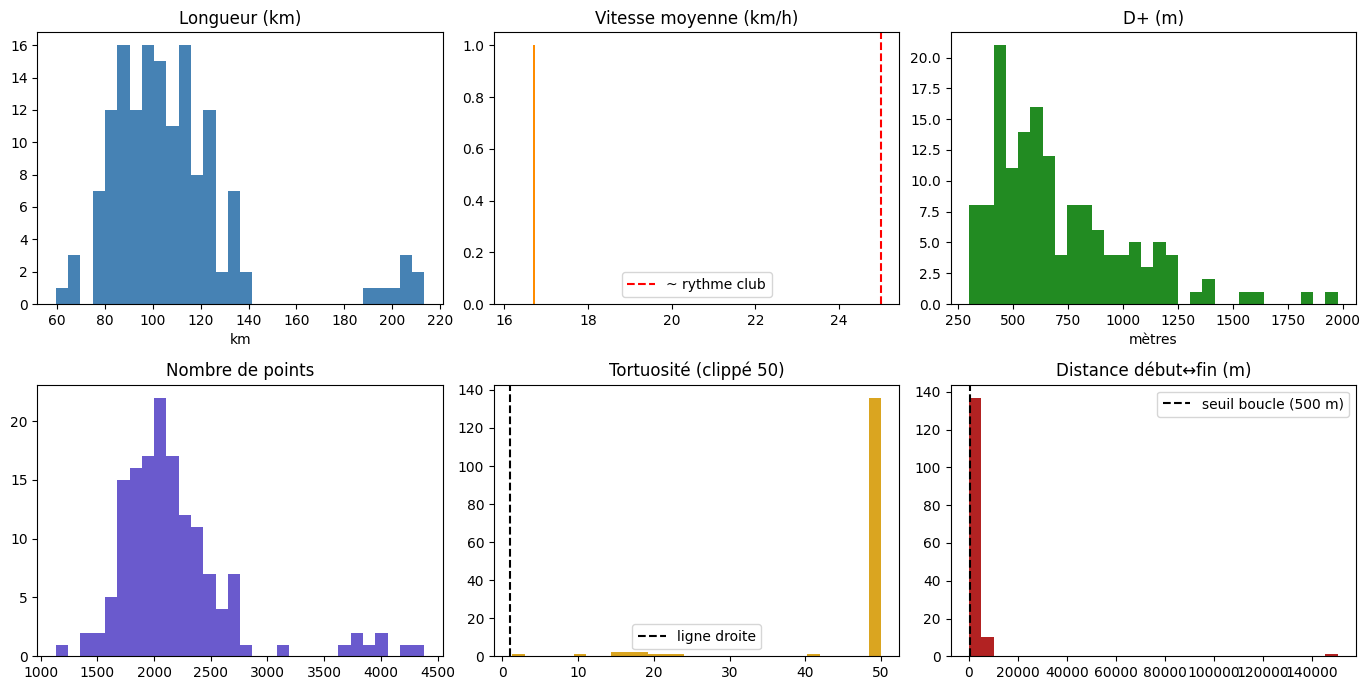

In [65]:
# Histogrammes des principales features
fig, axes = plt.subplots(2, 3, figsize=(14, 7))

axes[0, 0].hist(df["length_m"] / 1000, bins=30, color="steelblue")
axes[0, 0].set_title("Longueur (km)")
axes[0, 0].set_xlabel("km")

sp = df["speed_kmh_mean"].dropna()
axes[0, 1].hist(sp, bins=30, color="darkorange")
axes[0, 1].set_title("Vitesse moyenne (km/h)")
axes[0, 1].axvline(25, color="red", linestyle="--", label="~ rythme club")
axes[0, 1].legend()

axes[0, 2].hist(df["elevation_gain_m"], bins=30, color="forestgreen")
axes[0, 2].set_title("D+ (m)")
axes[0, 2].set_xlabel("mètres")

axes[1, 0].hist(df["n_points"], bins=30, color="slateblue")
axes[1, 0].set_title("Nombre de points")

axes[1, 1].hist(df["tortuosity"].clip(upper=50), bins=30, color="goldenrod")
axes[1, 1].set_title("Tortuosité (clippé 50)")
axes[1, 1].axvline(1, color="black", linestyle="--", label="ligne droite")
axes[1, 1].legend()

axes[1, 2].hist(df["start_end_crow_m"], bins=30, color="firebrick")
axes[1, 2].set_title("Distance début↔fin (m)")
axes[1, 2].axvline(LOOP_THRESHOLD_M, color="black", linestyle="--",
                   label=f"seuil boucle ({LOOP_THRESHOLD_M} m)")
axes[1, 2].legend()

plt.tight_layout()
plt.show()

In [66]:
# Les 5 traces avec la plus grande distance début↔fin
df.nlargest(5, "start_end_crow_m")[
    ["filename", "length_m", "start_end_crow_m", "tortuosity"]
]

,filename,length_m,start_end_crow_m,tortuosity
135,Les 200 du CSP - Pantin - Dieppe.gpx,203779.157618,150430.641437,1.354639
127,DRPA 02 (66km 505d+).gpx,66115.781412,6027.285270,10.969413
128,DRPA 02+ (99km 700d+).gpx,98589.643753,6027.285270,16.357222
129,DRPA 02++ (115km 892d+).gpx,115331.301967,6027.285270,19.134867
143,"PaDr 1+ (121km, 814d+).gpx",121430.443798,5935.538976,20.458200


## 8. Filtrage géographique Île-de-France

Une trace est "IdF" si sa bounding box intersecte celle de l'IdF élargie.
Critère large pour ne pas exclure les sorties qui débordent un peu (Oise, Eure).

In [67]:
def bbox_intersects(b1, b2) -> bool:
    """b = (lon_min, lat_min, lon_max, lat_max)"""
    return not (b1[2] < b2[0] or b1[0] > b2[2]
                or b1[3] < b2[1] or b1[1] > b2[3])


def trace_bbox(r):
    return (r["bbox_lon_min"], r["bbox_lat_min"],
            r["bbox_lon_max"], r["bbox_lat_max"])


df["is_idf"] = df.apply(
    lambda r: bbox_intersects(trace_bbox(r), IDF_BBOX), axis=1
)
print(f"Traces IdF        : {df['is_idf'].sum()} / {len(df)}")
print(f"Boucles IdF       : {(df['is_loop'] & df['is_idf']).sum()}")
print(f"→ EXPLOITABLES    : {(df['is_loop'] & df['is_idf']).sum()}")

Traces IdF        : 148 / 148
Boucles IdF       : 128
→ EXPLOITABLES    : 128


## 9. Visualisation

### Carte A : toutes les boucles IdF superposées

Par empilement de polylines semi-transparentes, on obtient une "heatmap
visuelle" qui révèle les territoires couverts. Les zones denses = couloirs
où la banque est riche. Les zones vides = zones à enrichir par d'autres
sources (Strava Segments, OSM).

In [68]:
# Filtrage géographique Île-de-France
# On garde les traces dont la bbox intersecte celle de l'IdF élargie
IDF_BBOX = (1.2, 48.0, 3.6, 49.3)

def bbox_intersects(b1, b2):
    """b = (lon_min, lat_min, lon_max, lat_max)"""
    return not (b1[2] < b2[0] or b1[0] > b2[2]
                or b1[3] < b2[1] or b1[1] > b2[3])

def trace_bbox(r):
    return (r["bbox_lon_min"], r["bbox_lat_min"],
            r["bbox_lon_max"], r["bbox_lat_max"])

df["is_idf"] = df.apply(
    lambda r: bbox_intersects(trace_bbox(r), IDF_BBOX), axis=1
)
print(f"Traces IdF        : {df['is_idf'].sum()} / {len(df)}")
print(f"Boucles IdF       : {(df['is_loop'] & df['is_idf']).sum()}")

Traces IdF        : 148 / 148
Boucles IdF       : 128


In [76]:
def downsample(pts, max_points=150):
    """Sous-échantillonne uniformément pour l'affichage."""
    if len(pts) <= max_points:
        return pts
    idx = np.linspace(0, len(pts) - 1, max_points, dtype=int)
    return [pts[i] for i in idx]


# Mapping rapide path → points parsés
points_by_path = {tr["path"]: tr["points"] for tr in ok}

df_usable = df[df["is_loop"] & df["is_idf"]]
print(f"Affichage de {len(df_usable)} boucles IdF")

m_all = folium.Map(
    location=[48.86, 2.35],
    zoom_start=9,
    tiles="cartodbpositron"
)

for _, row in tqdm(df_usable.iterrows(), total=len(df_usable), desc="Layers"):
    pts = points_by_path.get(row["path"])
    if not pts:
        continue
    pts_ds = downsample(pts, 150)
    latlon = [(p["lat"], p["lon"]) for p in pts_ds]
    folium.PolyLine(
        latlon,
        color="blue",
        weight=1.5,
        opacity=0.3,      # empilement = effet heatmap
        tooltip=row["filename"],
    ).add_to(m_all)

m_all

Affichage de 128 boucles IdF


Layers: 100%|██████████| 128/128 [00:00<00:00, 1496.60it/s]


### Carte B : inspection d'une trace individuelle

Change l'index `INSPECT_IDX` pour explorer différentes traces. Utile pour QC
manuel des traces flaggées non-boucles, ou juste pour voir la tête d'une
sortie.

In [70]:
INSPECT_IDX = 0    # change pour explorer d'autres traces

row = df.iloc[INSPECT_IDX]
pts = points_by_path[row["path"]]
lats = [p["lat"] for p in pts]
lons = [p["lon"] for p in pts]

m_one = folium.Map(
    location=[np.mean(lats), np.mean(lons)],
    zoom_start=12,
    tiles="OpenStreetMap"
)
folium.PolyLine(
    list(zip(lats, lons)),
    color="crimson",
    weight=3,
    opacity=0.8,
).add_to(m_one)
folium.Marker(
    [lats[0], lons[0]], tooltip="Départ",
    icon=folium.Icon(color="green")
).add_to(m_one)
folium.Marker(
    [lats[-1], lons[-1]], tooltip="Arrivée",
    icon=folium.Icon(color="red")
).add_to(m_one)

print(f"Trace : {row['filename']}")
print(f"  Longueur  : {row['length_m']/1000:.1f} km")
print(f"  D+        : {row['elevation_gain_m']:.0f} m")

print(f"  Difficulté parsée : {row['parsed_difficulty']}")
print(f"  Boucle    : {row['is_loop']}")
m_one

Trace : 200 by CSP - Décembre.gpx
  Longueur  : 213.5 km
  D+        : 984 m
  Difficulté parsée : facile
  Boucle    : False


## 10. Stockage en PostGIS

On insère maintenant en base. Deux tables peuplées :
- `traces` : métadonnées + géométrie LINESTRING complète
- `trace_points` : tous les points bruts (utile pour ré-extraire le D+
  avec une méthode différente plus tard, ou ré-appliquer un map-matching)

### Note sur la géométrie PostGIS

On fournit la `LINESTRING` en **WKT** (Well-Known Text) : format texte
`LINESTRING(lon1 lat1, lon2 lat2, ...)`. PostGIS parse automatiquement
via `ST_GeomFromText(..., 4326)`.

**Attention à l'ordre** : PostGIS utilise `(longitude, latitude)`, pas
l'inverse. C'est le piège classique qui met tes géométries au milieu de
l'Atlantique.

In [71]:
def points_to_linestring_wkt(pts, max_points=5000):
    """
    Convertit une liste de points en WKT LINESTRING.
    Sous-échantillonne si trop de points (PostGIS gère très bien les
    millions, mais ralentit les requêtes si tu stockes 50k points par trace).
    Pour nous 5000 max = amplement suffisant pour du vélo.
    """
    if len(pts) > max_points:
        idx = np.linspace(0, len(pts) - 1, max_points, dtype=int)
        pts = [pts[i] for i in idx]
    coords = ", ".join(f"{p['lon']} {p['lat']}" for p in pts)
    return f"LINESTRING({coords})"


# Reset idempotent des tables (on re-parse depuis les GPX à chaque run)
# En prod tu ferais des UPSERT, ici on repart propre.
with engine.begin() as conn:
    conn.execute(text("TRUNCATE TABLE trace_points, traces RESTART IDENTITY CASCADE;"))
print("Tables vidées.")

Tables vidées.


In [72]:
# --- Insertion des traces et de leurs points ---
# Compatibilité schéma DB : on stocke la zone principale dans parsed_zone
df["parsed_zone"] = df["main_zone"]

parsed_by_path = {tr["path"]: tr for tr in ok}

insert_trace_sql = text("""
INSERT INTO traces (
    filename, path, name, source_type,
    n_points, length_m, duration_s, speed_kmh_mean,
    elevation_gain_m, elevation_loss_m, max_elevation_m, min_elevation_m,
    start_end_crow_m, is_loop, tortuosity,
    parsed_zone, parsed_distance_km, parsed_difficulty,
    bbox_lon_min, bbox_lat_min, bbox_lon_max, bbox_lat_max,
    is_idf,
    geom
) VALUES (
    :filename, :path, :name, :source_type,
    :n_points, :length_m, :duration_s, :speed_kmh_mean,
    :elevation_gain_m, :elevation_loss_m, :max_elevation_m, :min_elevation_m,
    :start_end_crow_m, :is_loop, :tortuosity,
    :parsed_zone, :parsed_distance_km, :parsed_difficulty,
    :bbox_lon_min, :bbox_lat_min, :bbox_lon_max, :bbox_lat_max,
    :is_idf,
    ST_GeomFromText(:geom_wkt, 4326)
)
RETURNING trace_id;
""")

insert_point_sql = text("""
INSERT INTO trace_points (trace_id, seq, lat, lon, ele, time)
VALUES (:trace_id, :seq, :lat, :lon, :ele, :time);
""")


def none_if_nan(v):
    """PostgreSQL veut NULL, pandas utilise NaN : on convertit."""
    if v is None:
        return None
    if isinstance(v, float) and np.isnan(v):
        return None
    return v


with engine.begin() as conn:
    for _, row in tqdm(df.iterrows(), total=len(df), desc="Insert DB"):
        pts = parsed_by_path[row["path"]]["points"]
        wkt_line = points_to_linestring_wkt(pts)

        # Params pour la requête traces
        params = {
            "filename":         row["filename"],
            "path":             row["path"],
            "name":             row["name"],
            "source_type":      row["source_type"],
            "n_points":         int(row["n_points"]),
            "length_m":         none_if_nan(row["length_m"]),
            "duration_s":       none_if_nan(row["duration_s"]),
            "speed_kmh_mean":   none_if_nan(row["speed_kmh_mean"]),
            "elevation_gain_m": none_if_nan(row["elevation_gain_m"]),
            "elevation_loss_m": none_if_nan(row["elevation_loss_m"]),
            "max_elevation_m":  none_if_nan(row["max_elevation_m"]),
            "min_elevation_m":  none_if_nan(row["min_elevation_m"]),
            "start_end_crow_m": none_if_nan(row["start_end_crow_m"]),
            "is_loop":          bool(row["is_loop"]),
            "tortuosity":       none_if_nan(row["tortuosity"]),
            "parsed_zone":      row["parsed_zone"],
            "parsed_distance_km": none_if_nan(row["parsed_distance_km"]),
            "parsed_difficulty": row["parsed_difficulty"],
            "bbox_lon_min":     float(row["bbox_lon_min"]),
            "bbox_lat_min":     float(row["bbox_lat_min"]),
            "bbox_lon_max":     float(row["bbox_lon_max"]),
            "bbox_lat_max":     float(row["bbox_lat_max"]),
            "is_idf":           bool(row["is_idf"]),
            "geom_wkt":         wkt_line,
        }
        trace_id = conn.execute(insert_trace_sql, params).scalar()

        # Insertion batch des points (executemany-like)
        point_params = [
            {
                "trace_id": trace_id,
                "seq":      i,
                "lat":      p["lat"],
                "lon":      p["lon"],
                "ele":      p["ele"],
                "time":     p["time"],
            }
            for i, p in enumerate(pts)
        ]
        if point_params:
            conn.execute(insert_point_sql, point_params)

print("\n✓ Insertion terminée")

Insert DB: 100%|██████████| 148/148 [01:59<00:00,  1.24it/s]


✓ Insertion terminée


### Vérification post-insertion

On fait quelques requêtes SQL pour valider que tout est bien en base et
que les géométries sont valides.

In [73]:
with engine.connect() as conn:
    n_traces = conn.execute(text("SELECT COUNT(*) FROM traces")).scalar()
    n_points = conn.execute(text("SELECT COUNT(*) FROM trace_points")).scalar()
    n_loops  = conn.execute(text("SELECT COUNT(*) FROM traces WHERE is_loop")).scalar()
    n_idf    = conn.execute(text("SELECT COUNT(*) FROM traces WHERE is_idf")).scalar()

    # Validation géométrique (PostGIS détecte les géométries corrompues)
    n_invalid = conn.execute(text("""
        SELECT COUNT(*) FROM traces WHERE NOT ST_IsValid(geom);
    """)).scalar()

    # Longueur totale cumulée de toutes les traces (en km, calculée par PostGIS)
    # ST_Length sur geography = mètres sur la sphère, on divise par 1000
    total_km = conn.execute(text("""
        SELECT SUM(ST_Length(geom::geography)) / 1000.0 FROM traces;
    """)).scalar()

print(f"Traces en base        : {n_traces}")
print(f"Points en base        : {n_points:,}")
print(f"Boucles               : {n_loops}")
print(f"IdF                   : {n_idf}")
print(f"Géométries invalides  : {n_invalid}")
print(f"Distance cumulée      : {total_km:,.0f} km")

Traces en base        : 148
Points en base        : 322,771
Boucles               : 128
IdF                   : 148
Géométries invalides  : 0
Distance cumulée      : 15,986 km


In [74]:
# Top des zones parsées
with engine.connect() as conn:
    zones = pd.read_sql(text("""
        SELECT parsed_zone, COUNT(*) AS n,
               ROUND(AVG(length_m)/1000) AS avg_km,
               ROUND(AVG(elevation_gain_m)) AS avg_dplus
        FROM traces
        WHERE parsed_zone IS NOT NULL
        GROUP BY parsed_zone
        ORDER BY n DESC;
    """), conn)
print("Répartition par zone :")
print(zones.to_string(index=False))

Répartition par zone :
           parsed_zone  n  avg_km  avg_dplus
           bords_marne 72   103.0      593.0
         plaine_77_sud 36   104.0      520.0
haute_vallee_chevreuse 32   115.0     1116.0
   oise_pays_de_france  5   125.0      802.0
        vexin_francais  2   208.0     1481.0
       petite_couronne  1    88.0      791.0


## 11. Rapport final et prochaines étapes

In [75]:
# --- Rapport final ---
print("=" * 60)
print("RAPPORT DE NOTEBOOK 1")
print("=" * 60)
print(f"Fichiers GPX scannés      : {len(gpx_files)}")
print(f"Parsing OK                : {len(ok)}")
print(f"Parsing KO                : {len(ko)}")
print()
print(f"Traces en DB              : {n_traces}")
print(f"Boucles valides           : {n_loops}")
print(f"En Île-de-France          : {n_idf}")
print(f"→ EXPLOITABLES (loop ∩ IdF) : "
      f"{(df['is_loop'] & df['is_idf']).sum()}")
print()
print(f"D+ moyen  : {df['elevation_gain_m'].mean():.0f} m")
print(f"D+ max    : {df['elevation_gain_m'].max():.0f} m")
print(f"Longueur moyenne : {df['length_m'].mean()/1000:.1f} km")
print("=" * 60)

# Export d'un CSV résumé pour partage au club
df.to_csv(OUTPUT_DIR / "trace_features.csv", index=False)
print(f"\nCSV exporté : {OUTPUT_DIR / 'trace_features.csv'}")

RAPPORT DE NOTEBOOK 1
Fichiers GPX scannés      : 149
Parsing OK                : 148
Parsing KO                : 0

Traces en DB              : 148
Boucles valides           : 128
En Île-de-France          : 148
→ EXPLOITABLES (loop ∩ IdF) : 128

D+ moyen  : 709 m
D+ max    : 1976 m
Longueur moyenne : 107.8 km

CSV exporté : C:\Users\rapha\Desktop\GPX projet\Data\intermediaire\trace_CSP\trace_features.csv


## Ce qu'on a accompli

✓ Schéma DB complet (10 tables) posé pour tout le projet
✓ Parsing robuste de tous les GPX avec gestion d'erreurs
✓ Features numériques (longueur, D+, tortuosité, etc.)
✓ Validation que les traces sont bien des boucles
✓ Extraction d'info depuis les noms de fichiers (zone, distance, difficulté)
✓ Filtrage géographique IdF
✓ Visualisation heatmap + inspection individuelle
✓ Stockage PostGIS avec géométries `LINESTRING` indexées

## Prochaine étape : Notebook 2 — Map-matching et sous-tronçons

1. Installation de Valhalla en Docker local (~15 min setup)
2. Pour chaque trace, appel à `/trace_route` avec profil `bicycle`
3. Récupération des `edge_ids` OSM parcourus → table `trace_edges`
4. **Découpage des boucles en sous-tronçons** de ~5-15 km (aux intersections
   majeures ou par segmentation uniforme) — c'est la brique qui permettra
   le stitching A→B plus tard
5. QC visuel systématique sur un échantillon

## Rappel des prochaines intégrations majeures

| Notebook | Source | Bénéfice |
|----------|--------|----------|
| 3 | Tags OSM (cycleway, highway, maxspeed, …) | Score de base sur tout le graphe |
| 3 | data.gouv.fr — pistes cyclables IdF | Infra officielle tracée |
| 3 | Strava Segments via OAuth officiel | Popularité mesurée, légal |
| 3 | climbfinder (scraping ou API si dispo) | Côtes identifiées pour mode grimpeur |
| 5 | PU learning sur 100 traces → score ML par arête | Généralisation "club-worthy" à tout l'IdF |
| App | Feedback users (user_ratings, user_reports) | Amélioration continue |

On part au Notebook 2 quand tu confirmes que celui-ci tourne ?
